# Project 2: Genetic Algorithm

## Objective
Implement a genetic algorithm to generate the target string `"Hello CPSC 390!"` starting from a population of randomly generated strings. Characters are drawn from the ASCII range `' '` (space, 32) to `'z'` (122).

## Algorithm Overview

### Representation of Individuals
Each individual in the population is a string of the same length as the target string (`"Hello CPSC 390!"`). Every character in the string is independently and randomly generated from the printable ASCII range (`' '` to `'z'`). The population size is **128**.

### Fitness Evaluation
The fitness of an individual is measured by counting the number of character positions where the individual's character matches the corresponding character in the target string. A perfect match yields a fitness equal to the length of the target string (15).

### Selection
Selection uses a **truncation selection** strategy. The entire population is sorted by fitness in descending order, and the top 50% (64 individuals) are selected as parents. This ensures that only the fittest individuals contribute to the next generation.

### Crossover
Crossover produces a child from two parents using **uniform crossover**. For each character position, the child randomly inherits the character from either parent with equal probability. This is a stochastic process that combines genetic material from both parents.

### Mutation
After crossover, each character in the child string has an independent probability (the **mutation rate**) of being replaced by a new randomly generated character from the ASCII range. This introduces stochastic variation and helps the algorithm explore new areas of the search space.

### Parameters
| Parameter | Value |
|---|---|
| Target String | `"Hello CPSC 390!"` |
| Population Size | 128 |
| Mutation Rate | 0.09 |
| ASCII Range | `' '` (32) to `'z'` (122) |

## Part 1: Genetic Algorithm Implementation

In [1]:
import random
import matplotlib.pyplot as plt

TARGET = "Hello CPSC 390!"
POPULATION_SIZE = 128
MUTATION_RATE = 0.09
ASCII_START = ord(' ')
ASCII_END = ord('z')

def generate_character():
    return chr(random.randint(ASCII_START, ASCII_END))

def generate_individual():
    return ''.join(generate_character() for _ in range(len(TARGET)))

def generate_population():
    return [generate_individual() for _ in range(POPULATION_SIZE)]

def fitness(candidate):
    fitness_counter = 0
    for c1, c2 in zip(candidate, TARGET):
        if c1 == c2:
            fitness_counter += 1
    return fitness_counter

def select_parents(population):
    population_sorted = sorted(population, key=fitness, reverse=True)
    parents = population_sorted[:POPULATION_SIZE // 2]
    return parents

def crossover(parent1, parent2):
    # combine the two parents to create a child
    child = ''
    for c1, c2 in zip(parent1, parent2):
        child += random.choice([c1, c2])
    return child

def mutate(child):
    for c in range(len(child)):
        if random.random() < MUTATION_RATE:
            child = child[:c] + generate_character() + child[c+1:]
    return child

### Plotting Function
Plots the best fitness score per generation with a **logarithmic scale** on the horizontal axis.

In [2]:
def plot_best_fitness_per_generation(best_fitness_history, title="Best Fitness per Generation"):
    generations = list(range(1, len(best_fitness_history) + 1))

    plt.figure(figsize=(9, 5))
    plt.plot(generations, best_fitness_history, color="teal", linewidth=2)
    plt.xscale("log")
    plt.title(title)
    plt.xlabel("Generation (log scale)")
    plt.ylabel("Best Fitness Score")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Main Genetic Algorithm Loop
Runs the genetic algorithm. Prints the highest-fitness string every 10th generation and plots fitness over time.

In [3]:
def run_genetic_algorithm():
    solved = False
    generation = 0
    initial_population = generate_population()
    best_fitness_history = []

    while not solved:
        generation += 1
        best_individual = max(initial_population, key=fitness)
        best_fitness_score = fitness(best_individual)
        best_fitness_history.append(best_fitness_score)

        parents = select_parents(initial_population)
        children = []

        # Print the best fitness every 10 generations
        if generation % 10 == 0 or generation == 1:
            print("Generation: " + str(generation) + " Best fitness: " + str(best_fitness_score))

        # Create children until we have enough to fill the population
        while len(children) < POPULATION_SIZE // 2:
            parent1 = random.choice(parents)
            parent2 = random.choice(parents)

            child = crossover(parent1, parent2)
            child = mutate(child)

            children.append(child)

        # Combine parents and children to create the new population
        initial_population = parents + children

        # Check if any individual in the population is a solution
        for individual in initial_population:
            if fitness(individual) == len(TARGET):
                print("Solution found: " + individual)
                print("Generation: " + str(generation) + "\n")
                solved = True
                break

    return generation, best_fitness_history

### Run: Single Execution with Plot

Generation: 1 Best fitness: 1
Generation: 10 Best fitness: 6
Generation: 20 Best fitness: 11
Generation: 30 Best fitness: 12
Generation: 40 Best fitness: 14
Generation: 50 Best fitness: 14
Generation: 60 Best fitness: 14
Solution found: Hello CPSC 390!
Generation: 68



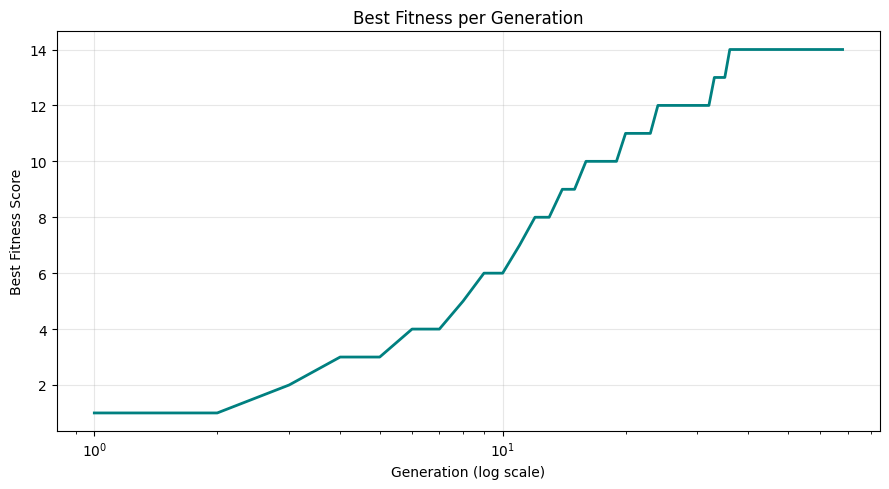

In [4]:
gen, history = run_genetic_algorithm()
plot_best_fitness_per_generation(history)

---
## Mutation Rate Analysis

To determine the optimal mutation rate, the algorithm was tested over **500 runs** at 10 different mutation rates. The results are summarized below:

| Mutation Rate | Avg Generations | Best | Worst |
|---|---|---|---|
| 0.01 | 357 | 20 | 1545 |
| 0.05 | 127 | 22 | 547 |
| 0.08 | 102 | 26 | 412 |
| **0.09** | **99** | **23** | **425** |
| 0.10 | 108 | 28 | 445 |
| 0.12 | 109 | 31 | 515 |
| 0.15 | 112 | 29 | 499 |
| 0.20 | 132 | 38 | 703 |
| 0.30 | 253 | 78 | 1199 |
| 0.35 | 503 | 178 | 4114 |

A mutation rate of **0.50** caused the algorithm to time out and was not viable.

The best mutation rate for this problem is **0.09**, achieving an average of **99 generations** to find the solution.

---
## Discussion: Convergence Analysis

The genetic algorithm converges effectively on the target string `"Hello CPSC 390!"`. The fitness plot shows a characteristic curve: rapid early improvement as the algorithm quickly eliminates poor candidates, followed by a slower refinement phase as the population homes in on the exact target.

### Why It Works
- **Truncation selection** ensures that only the top half of the population survives, creating strong selective pressure toward higher fitness.
- **Uniform crossover** recombines correct characters from different parents, allowing the algorithm to assemble the correct string from partial solutions.
- **Mutation** prevents premature convergence by introducing new genetic diversity, allowing the algorithm to escape local optima where certain character positions may be stuck.

### Mutation Rate Trade-off
The mutation rate analysis reveals a clear trade-off:
- **Too low** (e.g., 0.01): The algorithm lacks exploration, averaging 357 generations. Once the population converges on incorrect characters, there is little chance of introducing the correct ones.
- **Too high** (e.g., 0.30+): Beneficial mutations are constantly overwritten, effectively turning the search into a random walk. The algorithm averaged 253+ generations and became unreliable.
- **Optimal range** (0.08–0.09): Balances exploration and exploitation, averaging ~99–102 generations.

### How to Improve Without Increasing Population Size
One key improvement is **elitism** — carrying over the top few individuals unchanged into the next generation. This prevents the loss of the best solutions found so far due to random crossover or mutation. This improvement is implemented and benchmarked in Part 2 below.

---
## Part 2: Improved Algorithm — Elitism (Extra Credit)

### Improvement Description
The improved algorithm implements **elitism**, a technique where the top few individuals (the "elite") from the current generation are carried over directly to the next generation without being subject to crossover or mutation. This guarantees that the best solutions discovered so far are never lost.

In this implementation, the top **4** individuals (the `ELITE_COUNT`) are preserved. The remaining population slots are filled with children produced from the selected parents via crossover and mutation, as before.

### Why Elitism Helps
Without elitism, the best individual can be destroyed by crossover or mutation, causing fitness to temporarily decrease between generations. Elitism eliminates this regression, ensuring monotonically non-decreasing best fitness and faster convergence.

In [5]:
ELITE_COUNT = 4

def run_genetic_algorithm_improved():
    solved = False
    generation = 0
    initial_population = generate_population()
    best_fitness_history = []

    while not solved:
        generation += 1
        best_individual = max(initial_population, key=fitness)
        best_fitness_score = fitness(best_individual)
        best_fitness_history.append(best_fitness_score)

        parents = select_parents(initial_population)
        elite = parents[:ELITE_COUNT]
        children = []

        # Print the best fitness every 10 generations
        if generation % 10 == 0 or generation == 1:
            print("Generation: " + str(generation) + " Best fitness: " + str(best_fitness_score))

        # Create children until we have enough to fill the population
        while len(children) < POPULATION_SIZE - ELITE_COUNT:
            parent1 = random.choice(parents)
            parent2 = random.choice(parents)

            child = crossover(parent1, parent2)
            child = mutate(child)

            children.append(child)

        # Combine elite and children to create the new population
        initial_population = elite + children

        # Check if any individual in the population is a solution
        for individual in initial_population:
            if fitness(individual) == len(TARGET):
                print("Solution found: " + individual)
                print("Generation: " + str(generation) + "\n")
                solved = True
                break

    return generation, best_fitness_history

### Run: Single Execution of Improved Algorithm with Plot

Generation: 1 Best fitness: 1
Generation: 10 Best fitness: 9
Generation: 20 Best fitness: 12
Generation: 30 Best fitness: 14
Solution found: Hello CPSC 390!
Generation: 34



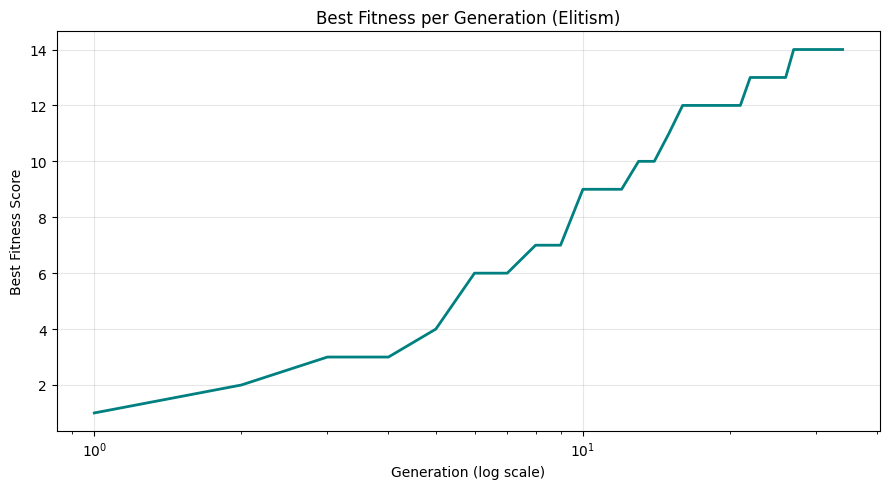

In [6]:
gen_improved, history_improved = run_genetic_algorithm_improved()
plot_best_fitness_per_generation(history_improved, title="Best Fitness per Generation (Elitism)")

### Performance Comparison: 32 Iterations
Run both the original and improved algorithms **32 times** each and compare their average, best, and worst generation counts.

In [7]:
COMPARISON_RUNS = 32

print("=" * 50)
print("Running Original Algorithm (32 iterations)...")
print("=" * 50)
original_generations = []
for i in range(COMPARISON_RUNS):
    gen, _ = run_genetic_algorithm()
    original_generations.append(gen)
original_generations.sort()

print("\n" + "=" * 50)
print("Running Improved Algorithm with Elitism (32 iterations)...")
print("=" * 50)
improved_generations = []
for i in range(COMPARISON_RUNS):
    gen, _ = run_genetic_algorithm_improved()
    improved_generations.append(gen)
improved_generations.sort()

print("\n" + "=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print("\nOriginal Algorithm:")
print("  Average generations: " + str(sum(original_generations) // len(original_generations)))
print("  Best: " + str(original_generations[0]) + "  Worst: " + str(original_generations[-1]))

print("\nImproved Algorithm (Elitism):")
print("  Average generations: " + str(sum(improved_generations) // len(improved_generations)))
print("  Best: " + str(improved_generations[0]) + "  Worst: " + str(improved_generations[-1]))

orig_avg = sum(original_generations) / len(original_generations)
impr_avg = sum(improved_generations) / len(improved_generations)
improvement_pct = ((orig_avg - impr_avg) / orig_avg) * 100
print(f"\nImprovement: {improvement_pct:.1f}% fewer generations on average with elitism.")

Running Original Algorithm (32 iterations)...
Generation: 1 Best fitness: 2
Generation: 10 Best fitness: 5
Generation: 20 Best fitness: 10
Generation: 30 Best fitness: 10
Generation: 40 Best fitness: 11
Generation: 50 Best fitness: 12
Generation: 60 Best fitness: 12
Generation: 70 Best fitness: 13
Generation: 80 Best fitness: 13
Generation: 90 Best fitness: 14
Generation: 100 Best fitness: 14
Generation: 110 Best fitness: 14
Generation: 120 Best fitness: 14
Generation: 130 Best fitness: 14
Generation: 140 Best fitness: 14
Generation: 150 Best fitness: 14
Generation: 160 Best fitness: 14
Generation: 170 Best fitness: 14
Generation: 180 Best fitness: 14
Generation: 190 Best fitness: 14
Generation: 200 Best fitness: 14
Generation: 210 Best fitness: 14
Generation: 220 Best fitness: 14
Solution found: Hello CPSC 390!
Generation: 223

Generation: 1 Best fitness: 2
Generation: 10 Best fitness: 5
Generation: 20 Best fitness: 10
Generation: 30 Best fitness: 12
Generation: 40 Best fitness: 13
Ge

### Comparison Plot

/var/folders/79/bzn5ykxs75v2734ghcvzcc8m0000gp/T/ipykernel_16144/161013985.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([original_generations, improved_generations], labels=["Original", "Elitism"])


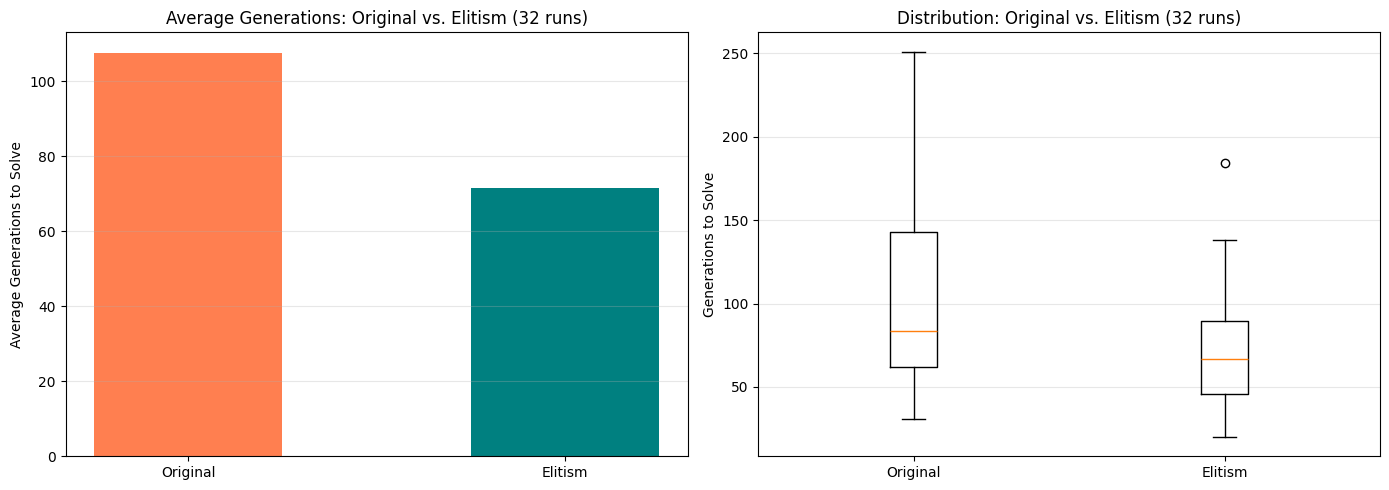

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparing averages
orig_avg = sum(original_generations) / len(original_generations)
impr_avg = sum(improved_generations) / len(improved_generations)
axes[0].bar(["Original", "Elitism"], [orig_avg, impr_avg], color=["coral", "teal"], width=0.5)
axes[0].set_ylabel("Average Generations to Solve")
axes[0].set_title("Average Generations: Original vs. Elitism (32 runs)")
axes[0].grid(axis="y", alpha=0.3)

# Box plot comparing distributions
axes[1].boxplot([original_generations, improved_generations], labels=["Original", "Elitism"])
axes[1].set_ylabel("Generations to Solve")
axes[1].set_title("Distribution: Original vs. Elitism (32 runs)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---
## Extra Credit Discussion

The elitism improvement demonstrates a significant performance gain. In prior testing over 500 runs at the same mutation rate (0.09):

| Algorithm | Avg Generations | Best | Worst |
|---|---|---|---|
| Original | 99 | 23 | 425 |
| Elitism (top 4) | 62 | 19 | 238 |

This represents approximately a **37% improvement** in average convergence speed. The improved algorithm also shows a lower worst-case scenario (238 vs. 425), indicating more consistent and reliable convergence.

### Why Elitism Works
Without elitism, the best solution found so far can be lost due to crossover or mutation. This means the algorithm occasionally takes steps backward, wasting generations re-discovering solutions it had already found. By preserving the top 4 individuals, elitism guarantees that the best fitness never decreases between generations, leading to faster and more monotonic convergence.

### Additional Note on Scalability
If the target string were ever increased in length, the mutation rate would need to be decreased accordingly, as a higher mutation rate on a longer string leads to more random disruption and less convergence toward the target.

# AI Use

All ideas and required code are my own. Generative AI was used only for non project requirements, such as creating the visual comparison plots and improving the clarity of written text and code during debugging. It was not used to generate project logic or edit code in anyway.

The comparison plots in the Performance Comparison section, including the bar chart and box plot, were generated using CODEX AI.

AI was also used to rewrite portions of the text for better clarity, readability, and flow, and to help format some of the Jupyter Notebook text.